# Compressible flow: nozzles and shock waves

Isentropic flow of a perfect gas ($k = 1.4$ for air) through a converging–diverging nozzle.

In [1]:
try:
    import fluidmech
except ImportError:  # e.g. on Google Colab
    %pip install -q git+https://github.com/ktwyw/fluidmech.git
    import fluidmech
print("fluidmech", fluidmech.__version__)

fluidmech 0.3.0


In [2]:
import matplotlib.pyplot as plt
from fluidmech import compressible as c

## 1. The area–Mach relation

$$\frac{A}{A^*} = \frac{1}{M}\left[\frac{2}{k+1}\left(1 + \frac{k-1}{2}M^2\right)\right]^{\frac{k+1}{2(k-1)}}$$

Each area ratio has a subsonic and a supersonic solution — which one occurs depends on the
back pressure.

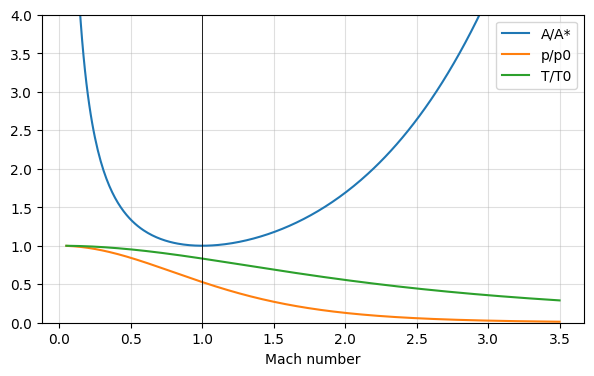

In [3]:
ms = [0.05 + 0.01 * i for i in range(346)]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ms, [c.area_ratio(m) for m in ms], label="A/A*")
ax.plot(ms, [c.pressure_ratio(m) for m in ms], label="p/p0")
ax.plot(ms, [c.temperature_ratio(m) for m in ms], label="T/T0")
ax.axvline(1, color="k", lw=0.6); ax.set_ylim(0, 4); ax.set_xlabel("Mach number")
ax.legend(); ax.grid(alpha=0.4); plt.show()

## 2. Designing a Mach 2.5 nozzle

throat 12.69 cm2, exit 33.47 cm2, exit pressure 41.0 kPa


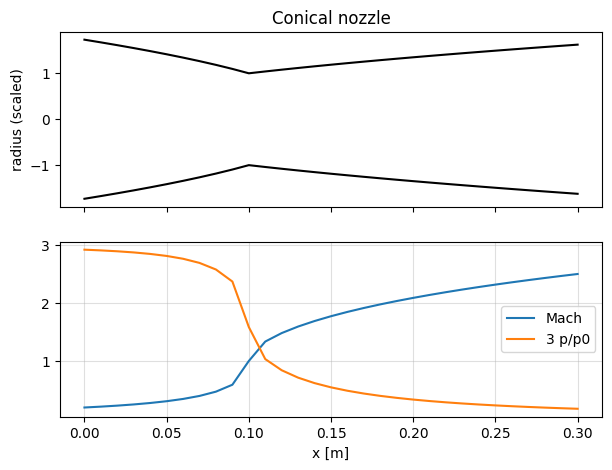

In [4]:
p0, T0, m_dot, Me = 700e3, 300.0, 1.5, 2.5
A_throat = m_dot / c.choked_mass_flow(1.0, p0, T0)
A_exit = A_throat * c.area_ratio(Me)
print(f"throat {A_throat*1e4:.2f} cm2, exit {A_exit*1e4:.2f} cm2, exit pressure {p0*c.pressure_ratio(Me)/1e3:.1f} kPa")

xs = [i / 100 for i in range(31)]
ratio = [3 - 20 * x if x <= 0.1 else 1 + (c.area_ratio(Me) - 1) * (x - 0.1) / 0.2 for x in xs]
mach = [c.mach_from_area_ratio(r, supersonic=x > 0.1) for x, r in zip(xs, ratio)]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
a1.plot(xs, [r ** 0.5 for r in ratio], "k"); a1.plot(xs, [-(r ** 0.5) for r in ratio], "k")
a1.set_ylabel("radius (scaled)"); a1.set_title("Conical nozzle")
a2.plot(xs, mach, label="Mach"); a2.plot(xs, [c.pressure_ratio(m) * 3 for m in mach], label="3 p/p0")
a2.set_xlabel("x [m]"); a2.legend(); a2.grid(alpha=0.4); plt.show()

## 3. Normal shocks

A shock is irreversible: static pressure jumps up, but stagnation pressure is lost.

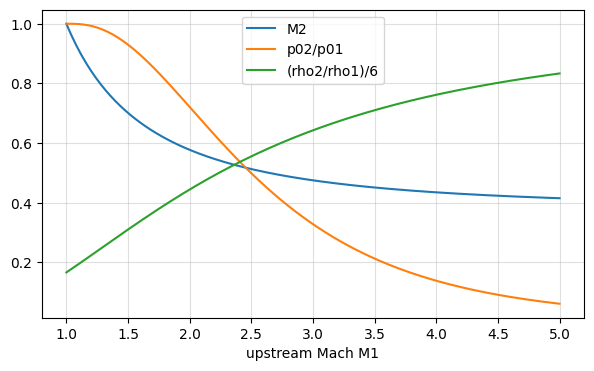

In [5]:
m1 = [1 + 0.02 * i for i in range(201)]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(m1, [c.normal_shock(m).mach2 for m in m1], label="M2")
ax.plot(m1, [c.normal_shock(m).stagnation_pressure_ratio for m in m1], label="p02/p01")
ax.plot(m1, [c.normal_shock(m).density_ratio / 6 for m in m1], label="(rho2/rho1)/6")
ax.set_xlabel("upstream Mach M1"); ax.legend(); ax.grid(alpha=0.4); plt.show()